## Importing Libraries


In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt



I0000 00:00:1788689325.061828    8402 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788689325.104494    8402 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788689326.043201    8402 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Load our model


In [4]:
model = tf.keras.models.load_model('trained_model.keras')

W0000 00:00:1788689329.013810    8402 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1788689329.016031    8402 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1788689329.175862    8402 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5219 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [5]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,283,380 (12.53 MB)

 Trainable params: 340,774 (1.30 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

 Optimizer params: 681,550 (2.60 MB)

## Visualizing Single Image of Test Set


In [ ]:
#%pip install opencv-python


Note: you may need to restart the kernel to use updated packages.


In [ ]:
#%pip freeze > main_requirements.txt



Note: you may need to restart the kernel to use updated packages.


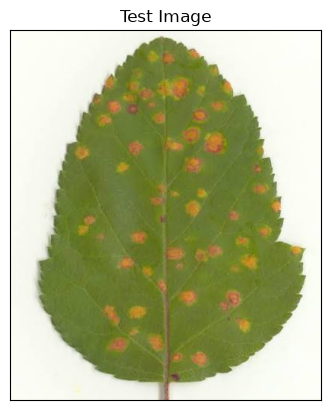

In [ ]:
import cv2
image_path = "apple_cedar_rust.jpg"

# Reading Image ~
img = cv2.imread(image_path)

# Convert the BGR image to RGB format
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# Displaying Image 
plt.imshow(img)
plt.title("Test Image")

# To remove the X-Axis and the Y-Axis values 
plt.xticks([])
plt.yticks([])
plt.show()

## Testing Model

In [10]:
image = tf.keras.preprocessing.image.load_img(image_path, target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])   #Convert the single image to the batch
print(input_arr.shape)

(1, 128, 128, 3)


In [11]:
prediction = model.predict(input_arr)
prediction, prediction.shape

I0000 00:00:1788689582.180933    8703 cuda_dnn.cc:461] Loaded cuDNN version 92400


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


(array([[2.63427454e-03, 1.53049737e-01, 5.73164821e-01, 3.63912804e-05,
         1.56076407e-04, 1.38405987e-04, 1.39031345e-02, 6.53919560e-05,
         1.33240770e-04, 2.04479111e-05, 5.12223342e-05, 1.44421519e-03,
         3.28178448e-03, 5.35381041e-05, 3.67294485e-03, 4.52217972e-03,
         9.07461508e-04, 1.87975078e-04, 1.34652876e-03, 2.67112064e-05,
         7.88139459e-06, 9.13978397e-07, 8.24141665e-04, 1.27234953e-02,
         9.74431623e-06, 4.86176345e-04, 4.31861319e-02, 1.83892712e-01,
         2.76228752e-06, 2.21328378e-07, 1.13892163e-07, 3.87354113e-08,
         6.26260080e-05, 9.63585194e-08, 7.40962776e-08, 5.80658707e-07,
         5.27573820e-06, 5.42209818e-07]], dtype=float32),
 (1, 38))

In [12]:
result_idx = np.argmax(prediction)
result_idx

np.int64(2)

In [13]:
class_name = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

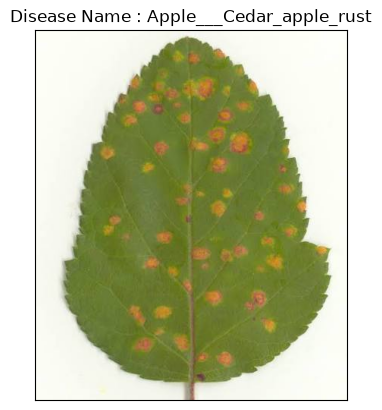

In [14]:
# Displaying Result of disease preediction
model_prediction = class_name[result_idx]
plt.imshow(img)
plt.title(f"Disease Name : {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()